***Project 3 EEP 153***

**Authors:** Daniel Canales, Amanda Edwards, Christian Gee, Ziton Xu, Chloe Shih

In [2]:
!pip install -r requirements.txt

  Using cached cfedemands-0.8.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached consumerdemands-0.5.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached ligonlibrary-0.2.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached gspread_pandas-3.3.0-py2.py3-none-any.whl.metadata (10 kB)
  Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached python_gnupg-0.5.6-py2.py3-none-any.whl.metadata (2.1 kB)
  Using cached python_magic-0.4.27-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached thefuzz-0.22.1-py3-none-any.whl.metadata (3.9 kB)
Using cached cfedemands-0.8.2-py3-none-any.whl (98 kB)
Using cached consumerdemands-0.5.0-py3-none-any.whl (14 kB)
Using cached ligonlibrary-0.2.0-py3-none-any.whl (19 kB)
Using cached gspread_pandas-3.3.0-py2.py3-none-any.whl (27 kB)
Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.3 MB)
Using

In [3]:
Panama_data = 'https://docs.google.com/spreadsheets/d/1tYmqzz4VqM5rd4aeO6zB4wL9ADcoTdvTPKZF5zgX7a4/edit?gid=1443689638#gid=1443689638'

In [4]:
import pandas as pd 
import numpy as np
from ligonlibrary.sheets import read_sheets

### Sheets to DataFrames (Panama) 

In [5]:
x = read_sheets(Panama_data, sheet='Food Expenditures (2008)')
p = read_sheets(Panama_data, sheet='Food Prices (2008)')
d = read_sheets(Panama_data, sheet='Household Characteristics')

In [6]:
x.head()
p.head()
d.head()

,i,t,m,men,women,girls,boys,Males 00-03,Females 00-03,Males 04-08,...,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,log HSize
0,1997125,1997,Herrera,1,1,0,1,0,0,0,...,0,0,0,0,0,0,1,1,0,1.098612
1,1997160,1997,Herrera,1,2,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,1.098612
2,1997170,1997,Bocas Del Toro,1,1,4,3,1,2,1,...,1,1,1,0,0,0,1,1,0,2.197225
3,1997177,1997,Bocas Del Toro,1,4,5,9,2,1,4,...,3,2,0,0,2,0,2,1,0,2.944439
4,1997178,1997,Bocas Del Toro,2,2,2,1,0,0,0,...,0,0,1,2,0,0,1,0,1,1.945910


In [7]:
x.head()
x.columns

Index(['i', 't', 'm', 'j', 'Expenditure'], dtype='str')

In [8]:
x.head()

,i,t,m,j,Expenditure
0,20081,2008,Bocas Del Toro,Ahí Verde,0.75
1,20081,2008,Bocas Del Toro,Arroz,7.35
2,20081,2008,Bocas Del Toro,Arvejas,0.75
3,20081,2008,Bocas Del Toro,Azúcar,1.60
4,20081,2008,Bocas Del Toro,Carne De Res,18.00


In [9]:
# Convert expenditure data from long to wide
x = x.pivot_table(
    index='i',
    columns='j',
    values='Expenditure',
    aggfunc='sum'
)

x.head()

j,Aceite Vegetal,Aguacates,Ahí Verde,Ajo,Alimento Infantil,Apio,Arroz,Arvejas,Azúcar,Café Y Té,...,Sardina Y Atún,"Sodas, Refrescos Y Jugos",Sopa Enlatada,Tomate,Viscera De Res,Visceras De Pollo O Gallina,Yuca,Zanahoria,Zapallo / Chayote,Ñame
i,,,,,,,,,,,,,,,,,,,,,
20081,NaN,NaN,0.75,NaN,NaN,NaN,7.35,0.75,1.60,NaN,...,0.55,3.0,0.9,1.6,NaN,NaN,0.7,0.80,0.5,NaN
20082,4.25,NaN,2.00,NaN,NaN,NaN,12.25,0.95,NaN,NaN,...,2.00,NaN,0.4,2.0,NaN,NaN,NaN,NaN,NaN,1.0
20083,4.50,3.00,0.80,NaN,NaN,NaN,2.45,NaN,1.75,NaN,...,NaN,5.0,1.8,2.5,NaN,NaN,NaN,NaN,NaN,NaN
20084,4.25,1.50,0.75,NaN,NaN,NaN,10.50,NaN,3.50,2.35,...,NaN,4.0,NaN,NaN,NaN,NaN,0.7,0.75,NaN,NaN
20085,4.25,2.25,1.50,NaN,NaN,1.5,4.90,NaN,NaN,NaN,...,NaN,35.0,1.8,NaN,NaN,NaN,NaN,NaN,0.5,1.6


In [10]:
d = d.set_index('i')
d.head()

,t,m,men,women,girls,boys,Males 00-03,Females 00-03,Males 04-08,Females 04-08,...,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,log HSize
i,,,,,,,,,,,,,,,,,,,,,
1997125,1997,Herrera,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,1,1,0,1.098612
1997160,1997,Herrera,1,2,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,1.098612
1997170,1997,Bocas Del Toro,1,1,4,3,1,2,1,0,...,1,1,1,0,0,0,1,1,0,2.197225
1997177,1997,Bocas Del Toro,1,4,5,9,2,1,4,1,...,3,2,0,0,2,0,2,1,0,2.944439
1997178,1997,Bocas Del Toro,2,2,2,1,0,0,0,1,...,0,0,1,2,0,0,1,0,1,1.945910


In [11]:
x = x.replace(0, np.nan)
y = np.log(x)
y.head()

j,Aceite Vegetal,Aguacates,Ahí Verde,Ajo,Alimento Infantil,Apio,Arroz,Arvejas,Azúcar,Café Y Té,...,Sardina Y Atún,"Sodas, Refrescos Y Jugos",Sopa Enlatada,Tomate,Viscera De Res,Visceras De Pollo O Gallina,Yuca,Zanahoria,Zapallo / Chayote,Ñame
i,,,,,,,,,,,,,,,,,,,,,
20081,NaN,NaN,-0.287682,NaN,NaN,NaN,1.994700,-0.287682,0.470004,NaN,...,-0.597837,1.098612,-0.105361,0.470004,NaN,NaN,-0.356675,-0.223144,-0.693147,NaN
20082,1.446919,NaN,0.693147,NaN,NaN,NaN,2.505526,-0.051293,NaN,NaN,...,0.693147,NaN,-0.916291,0.693147,NaN,NaN,NaN,NaN,NaN,0.000000
20083,1.504077,1.098612,-0.223144,NaN,NaN,NaN,0.896088,NaN,0.559616,NaN,...,NaN,1.609438,0.587787,0.916291,NaN,NaN,NaN,NaN,NaN,NaN
20084,1.446919,0.405465,-0.287682,NaN,NaN,NaN,2.351375,NaN,1.252763,0.854415,...,NaN,1.386294,NaN,NaN,NaN,NaN,-0.356675,-0.287682,NaN,NaN
20085,1.446919,0.810930,0.405465,NaN,NaN,0.405465,1.589235,NaN,NaN,NaN,...,NaN,3.555348,0.587787,NaN,NaN,NaN,NaN,NaN,-0.693147,0.470004


In [12]:
use = y.index.intersection(d.index)

y = y.loc[use]
d = d.loc[use]

print(y.shape)
print(d.shape)

(6836, 81)
(6836, 21)


### Estimation Panama

In [13]:
from cfe.estimation import drop_columns_wo_covariance
from cfe import Regression

x_raw = read_sheets(Panama_data, sheet='Food Expenditures (2008)')
d_raw = read_sheets(Panama_data, sheet='Household Characteristics')

y = (x_raw.set_index(['i', 't', 'm', 'j'])['Expenditure'].replace(0, np.nan))
y = np.log(y)

d = d_raw.set_index(['i', 't', 'm'])

result = Regression(y=y, d=d)

### Results Panama

In [14]:
result.get_beta()

j
Aceite Vegetal                  0.415991
Ajo                             0.288771
Arroz                           0.250081
Azúcar                          0.303668
Café Y Té                       0.307942
Carne De Res                    0.695826
Carnes De Puerco                0.613415
Cebolla                         0.467811
Cereales Y Cremas               0.642493
Cigarrillo Y Tabaco             0.962572
Condimentos                     0.615954
Embutidos                       0.634336
Frijoles                        0.260462
Galletas / Pasteles Y Dulces    0.662308
Harina De Trigo                 0.356053
Huevos De Gallina               0.458651
Lecha Evaporada                 0.545697
Leche En Polvo                  0.289263
Lentejas                        0.368234
Maíz De Grano                   0.292204
Pan De Sal Y Pan De Dulce       0.753623
Pastas Alimenticias             0.550472
Pastas De Tomate                0.503155
Pastillas Y Confites            0.729585
Pescados      

In [15]:
result.get_gamma()

k,men,women,girls,boys,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,log HSize,Constant
j,,,,,,,,,,,,,,,,,,,,
Aceite Vegetal,0.002533,-0.357269,-0.445817,-0.059863,-0.076538,0.363888,0.006827,0.373265,0.008509,0.395257,0.020255,0.377062,-0.008170,0.339975,-0.011209,0.404283,0.003178,0.339799,0.342120,1.184752
Ajo,0.027699,-0.110525,-0.214889,-0.011194,0.007124,0.225632,-0.024636,0.204637,0.009888,0.190763,0.023106,0.209420,-0.030596,0.084680,0.003987,0.102754,0.027529,0.125501,0.079852,-0.671768
Arroz,-0.272187,-0.614727,-0.552876,-0.292783,0.189522,0.472702,0.233456,0.475730,0.336911,0.569021,0.361623,0.556497,0.329595,0.541919,0.348750,0.514682,0.340383,0.553044,0.594265,1.903947
Azúcar,-0.431205,-0.358655,-0.295694,-0.433964,0.447565,0.358332,0.482738,0.372947,0.522795,0.386311,0.522234,0.347403,0.471047,0.333766,0.487860,0.364839,0.586129,0.425075,0.301190,0.439945
Café Y Té,0.097222,0.088335,0.159033,0.028359,0.018104,-0.114590,-0.040047,-0.133886,0.004860,-0.159876,0.033251,-0.089263,-0.053887,-0.113523,0.036092,-0.003167,0.127310,0.027610,-0.010536,0.658230
Carne De Res,0.595127,-2.285380,-2.504856,0.541709,-0.644467,2.372075,-0.649517,2.418631,-0.608824,2.415609,-0.628551,2.428312,-0.588648,2.271613,-0.530560,2.349904,-0.535828,2.253881,0.416919,1.972076
Carnes De Puerco,-0.546831,0.159425,0.033114,-0.624868,0.526590,-0.109814,0.588701,-0.092415,0.566078,-0.102491,0.630046,-0.082208,0.550530,-0.172967,0.608062,-0.144423,0.623627,-0.206983,0.306282,1.609093
Cebolla,-0.777071,0.076194,0.052334,-0.755154,0.744916,-0.052180,0.745508,-0.093531,0.737989,-0.046190,0.777949,-0.047138,0.788424,-0.084306,0.838118,-0.065677,0.881825,-0.050972,0.171356,-0.100548
Cereales Y Cremas,-0.052397,-0.130820,-0.263697,-0.102352,0.018835,0.198916,0.081181,0.218332,-0.029693,0.087692,-0.029286,0.106766,0.005311,0.090241,-0.040359,0.205524,-0.160620,0.042752,0.426647,0.768024


### Sheets to Data Frame (Serbia)

In [16]:
Serbia_data = 'https://docs.google.com/spreadsheets/d/1GFu5qKhA6kx2Qjadu7Gnr9853FpPcZxpO4QzAbLlWos/edit?gid=353863528#gid=353863528'

In [17]:
x = read_sheets(Serbia_data, sheet='Food Expenditures (2007)')
p = read_sheets(Serbia_data, sheet='Food Prices (2007)')
d = read_sheets(Serbia_data, sheet='Household Characteristics')

In [18]:
x.head()
p.head()
d.head()

,i,t,m,index,women,girls,boys,men,Males 00-03,Females 00-03,...,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,log HSize
0,7001700171001,2007,Sumadija,0,3,0,1,1,0,0,...,0,1,0,0,1,1,1,0,1,1.609438
1,7001700171002,2007,Sumadija,1,1,0,0,2,0,0,...,0,0,0,1,0,0,1,1,0,1.098612
2,7001700171004,2007,Sumadija,2,1,1,1,1,0,0,...,0,0,0,0,0,1,1,0,0,1.386294
3,7001700171005,2007,Sumadija,3,1,1,0,2,0,0,...,0,1,1,0,0,1,1,0,0,1.386294
4,7001700171007,2007,Sumadija,4,1,1,0,2,0,0,...,1,1,0,0,0,1,1,0,0,1.386294


In [19]:
x.head()
x.columns

Index(['i', 't', 'm', 'j', 'Expenditure'], dtype='str')

In [20]:
x = x.pivot_table(
    index='i',
    columns='j',
    values='Expenditure',
    aggfunc='sum'
)

x.head()

j,@ivinsko meso,Beli hleb,Cigarete,Crni i beli luk i praziluk,"Crni, ra`ani, integralni hleb","D@em, kompot, slatko, marmelada","Doma}i, beli sir (sve vrste)",Druge vrste `ita,Druge vrste hleba,Duvan,...,Vino,"Vir{le, debreciner, safalade",Za~ini,Zelena salata,"[argarepa, zelen, celer, cvekla,","[e}er (kristal, kocke, prah)","[lag, puding, i sl.",[ljive,^ajevi,^okolade i ~okoladni krem
i,,,,,,,,,,,,,,,,,,,,,
7001700171001,480.0,175.0,315.0,84.0,210.0,120.0,105.0,NaN,NaN,NaN,...,80.0,180.0,170.0,NaN,120.0,66.0,50.0,NaN,50.0,150.0
7001700171002,270.0,175.0,525.0,189.0,NaN,NaN,210.0,NaN,NaN,NaN,...,NaN,50.0,70.0,NaN,24.0,42.0,NaN,NaN,NaN,NaN
7001700171004,250.0,175.0,NaN,86.0,NaN,NaN,180.0,NaN,NaN,NaN,...,NaN,308.0,NaN,NaN,90.0,42.0,NaN,NaN,NaN,595.0
7001700171005,NaN,175.0,595.0,48.0,105.0,NaN,NaN,NaN,NaN,NaN,...,NaN,60.0,75.0,NaN,24.0,66.0,NaN,NaN,NaN,270.0
7001700171007,360.0,350.0,350.0,36.0,NaN,30.0,225.0,NaN,NaN,NaN,...,NaN,40.0,83.0,NaN,104.0,90.0,NaN,NaN,NaN,349.0


In [21]:
d = d.set_index('i')
d.head()

,t,m,index,women,girls,boys,men,Males 00-03,Females 00-03,Males 04-08,...,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,log HSize
i,,,,,,,,,,,,,,,,,,,,,
7001700171001,2007,Sumadija,0,3,0,1,1,0,0,0,...,0,1,0,0,1,1,1,0,1,1.609438
7001700171002,2007,Sumadija,1,1,0,0,2,0,0,0,...,0,0,0,1,0,0,1,1,0,1.098612
7001700171004,2007,Sumadija,2,1,1,1,1,0,0,0,...,0,0,0,0,0,1,1,0,0,1.386294
7001700171005,2007,Sumadija,3,1,1,0,2,0,0,0,...,0,1,1,0,0,1,1,0,0,1.386294
7001700171007,2007,Sumadija,4,1,1,0,2,0,0,0,...,1,1,0,0,0,1,1,0,0,1.386294


In [22]:
x = x.replace(0, np.nan)
y = np.log(x)
y.head()

j,@ivinsko meso,Beli hleb,Cigarete,Crni i beli luk i praziluk,"Crni, ra`ani, integralni hleb","D@em, kompot, slatko, marmelada","Doma}i, beli sir (sve vrste)",Druge vrste `ita,Druge vrste hleba,Duvan,...,Vino,"Vir{le, debreciner, safalade",Za~ini,Zelena salata,"[argarepa, zelen, celer, cvekla,","[e}er (kristal, kocke, prah)","[lag, puding, i sl.",[ljive,^ajevi,^okolade i ~okoladni krem
i,,,,,,,,,,,,,,,,,,,,,
7001700171001,6.173786,5.164786,5.752573,4.430817,5.347108,4.787492,4.653960,NaN,NaN,NaN,...,4.382027,5.192957,5.135798,NaN,4.787492,4.189655,3.912023,NaN,3.912023,5.010635
7001700171002,5.598422,5.164786,6.263398,5.241747,NaN,NaN,5.347108,NaN,NaN,NaN,...,NaN,3.912023,4.248495,NaN,3.178054,3.737670,NaN,NaN,NaN,NaN
7001700171004,5.521461,5.164786,NaN,4.454347,NaN,NaN,5.192957,NaN,NaN,NaN,...,NaN,5.730100,NaN,NaN,4.499810,3.737670,NaN,NaN,NaN,6.388561
7001700171005,NaN,5.164786,6.388561,3.871201,4.653960,NaN,NaN,NaN,NaN,NaN,...,NaN,4.094345,4.317488,NaN,3.178054,4.189655,NaN,NaN,NaN,5.598422
7001700171007,5.886104,5.857933,5.857933,3.583519,NaN,3.401197,5.416100,NaN,NaN,NaN,...,NaN,3.688879,4.418841,NaN,4.644391,4.499810,NaN,NaN,NaN,5.855072


In [23]:
use = y.index.intersection(d.index)

y = y.loc[use]
d = d.loc[use]

print(y.shape)
print(d.shape)

(5557, 100)
(5557, 22)


### Estimation Serbia

In [24]:
x_raw = read_sheets(Serbia_data, sheet='Food Expenditures (2007)')
d_raw = read_sheets(Serbia_data, sheet='Household Characteristics')

y = (x_raw.set_index(['i', 't', 'm', 'j'])['Expenditure'].replace(0, np.nan))
y = np.log(y)

d = d_raw.set_index(['i', 't', 'm'])

result = Regression(y=y, d=d)

/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Results Serbia

In [25]:
result.get_gamma()

k,index,women,girls,boys,men,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,...,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,log HSize,Constant
j,,,,,,,,,,,,,,,,,,,,,
@ivinsko meso,0.000009,0.232710,0.349327,-0.003340,0.001931,-0.031027,-0.456352,-0.071043,-0.394265,-0.024944,...,0.029966,-0.274645,0.041118,-0.240037,0.018848,-0.226987,0.035673,-0.249152,0.562766,5.334317
Beli hleb,0.000011,-1.192532,-1.105802,0.113762,0.117719,-0.078364,1.110451,-0.041102,1.146893,-0.007935,...,0.089765,1.223249,0.085039,1.219619,0.097784,1.220895,0.086294,1.254040,0.495698,5.150354
Cigarete,-0.000013,0.021664,-0.071711,-0.079493,0.133063,0.150312,0.020076,0.012614,-0.046396,0.032315,...,0.034709,0.011663,-0.017515,0.054380,-0.071135,0.026086,-0.087731,-0.130868,0.297146,6.170939
Crni i beli luk i praziluk,-0.000059,-0.043129,0.096239,0.035007,0.045481,-0.055525,-0.049040,-0.019985,-0.079979,0.019529,...,-0.044902,-0.032905,0.094345,0.073579,0.041139,0.119638,0.045887,0.104096,0.296041,3.519325
"Crni, ra`ani, integralni hleb",-0.000001,0.187450,-0.153124,0.134465,-0.162359,-0.290163,0.132083,-0.153482,0.080179,-0.123433,...,-0.100763,0.104630,0.216648,-0.203407,0.231587,-0.161292,0.191713,-0.039832,0.337760,4.502575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"[argarepa, zelen, celer, cvekla,",-0.000024,-0.083388,-0.153145,-0.076066,-0.024237,0.039917,0.141430,-0.015438,0.119807,0.106491,...,-0.000958,0.103739,-0.019918,0.024538,-0.112454,0.049912,-0.097944,0.039400,0.558450,3.375097
"[e}er (kristal, kocke, prah)",-0.000045,-0.066022,-0.130634,0.030068,0.024589,0.013751,0.111601,-0.030102,0.148985,0.027006,...,0.039115,0.187786,-0.015596,0.079726,-0.008898,0.098641,0.029380,0.117678,0.597762,3.591279
"[lag, puding, i sl.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Visualizations

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
gamma_pan = result.get_gamma()['Constant'].dropna().sort_values()
gamma_ser = result.get_gamma()['Constant'].dropna().sort_values()
pan_const = gamma_pan
ser_const = gamma_ser

In [39]:
# Checking for shared foods in diff languages
shared_foods = pan_const.index.intersection(ser_const.index)

if len(shared_foods) == 0:
    print("No shared food, plot grahps independently")
    use_shared = False
else:
    print(f"Found {len(shared_foods)} shared food items")
    use_shared = True
    combined = pd.DataFrame({
        'Panama': pan_const.loc[shared_foods],
        'Serbia': ser_const.loc[shared_foods]
    }).sort_values('Panama')

Found 73 shared food items


/tmp/ipykernel_107/4013767418.py:23: UserWarning: Glyph 133 (\x85) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/srv/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 133 (\x85) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


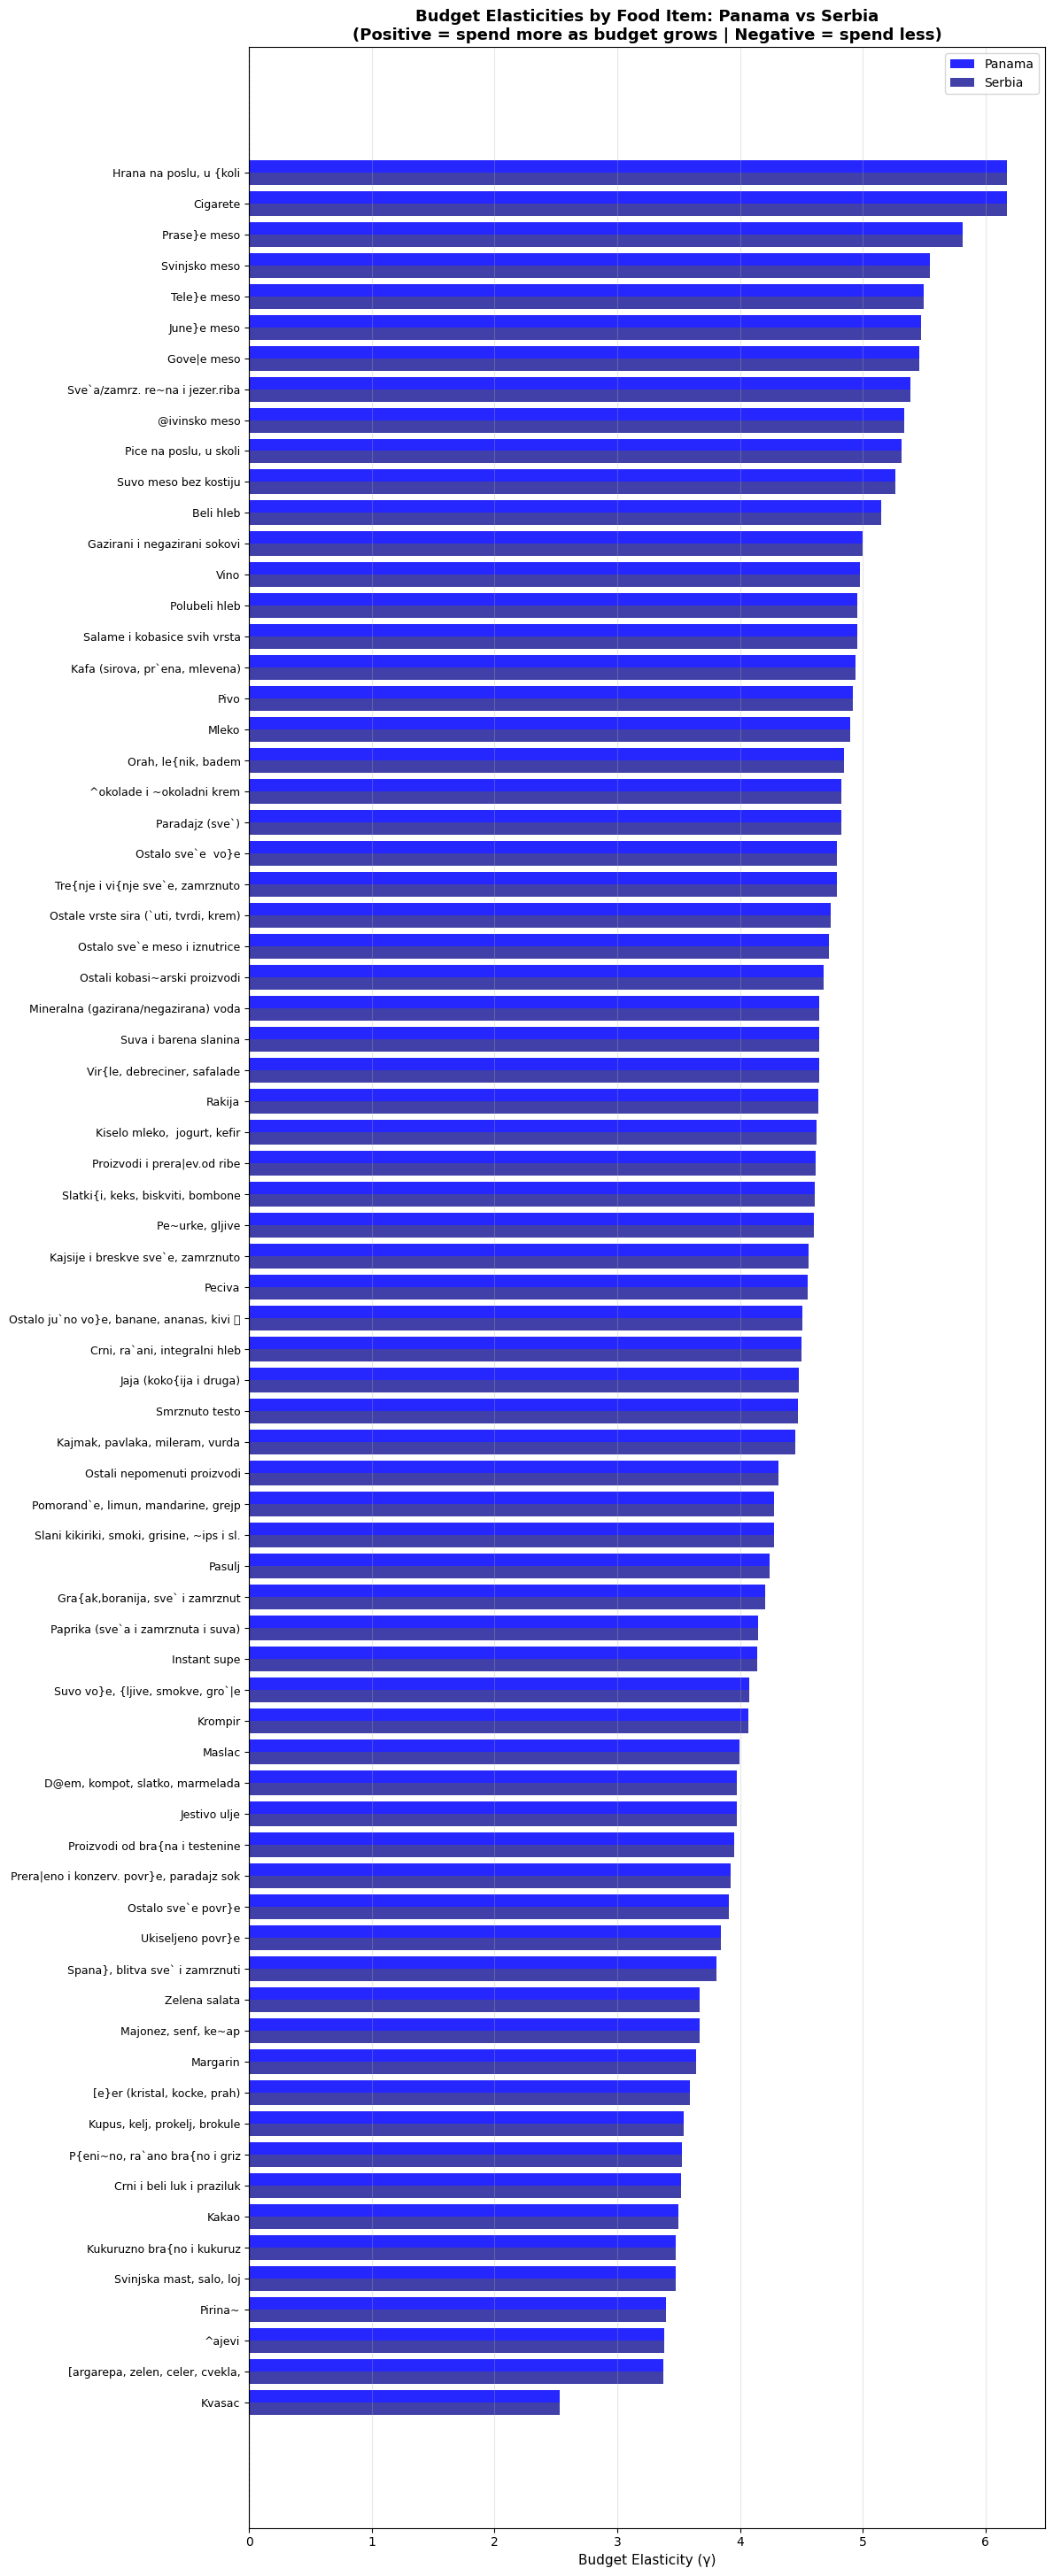

In [40]:
if use_shared:
    fig, ax = plt.subplots(figsize=(12, max(8, len(combined) * 0.4)))
    y_pos = np.arange(len(combined))
    bar_width = 0.4

    ax.barh(y_pos + bar_width/2, combined['Panama'], height=bar_width,
            color=['blue' if v >= 0 else 'red' for v in combined['Panama']],
            label='Panama', alpha=0.85)

    ax.barh(y_pos - bar_width/2, combined['Serbia'], height=bar_width,
            color=['darkblue' if v >= 0 else 'darkred' for v in combined['Serbia']],
            label='Serbia', alpha=0.75)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(combined.index, fontsize=9)
    ax.set_xlabel('Budget Elasticity (γ)', fontsize=11)
    ax.set_title('Budget Elasticities by Food Item: Panama vs Serbia\n'
                 '(Positive = spend more as budget grows | Negative = spend less)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("no overlapping food items between countries")

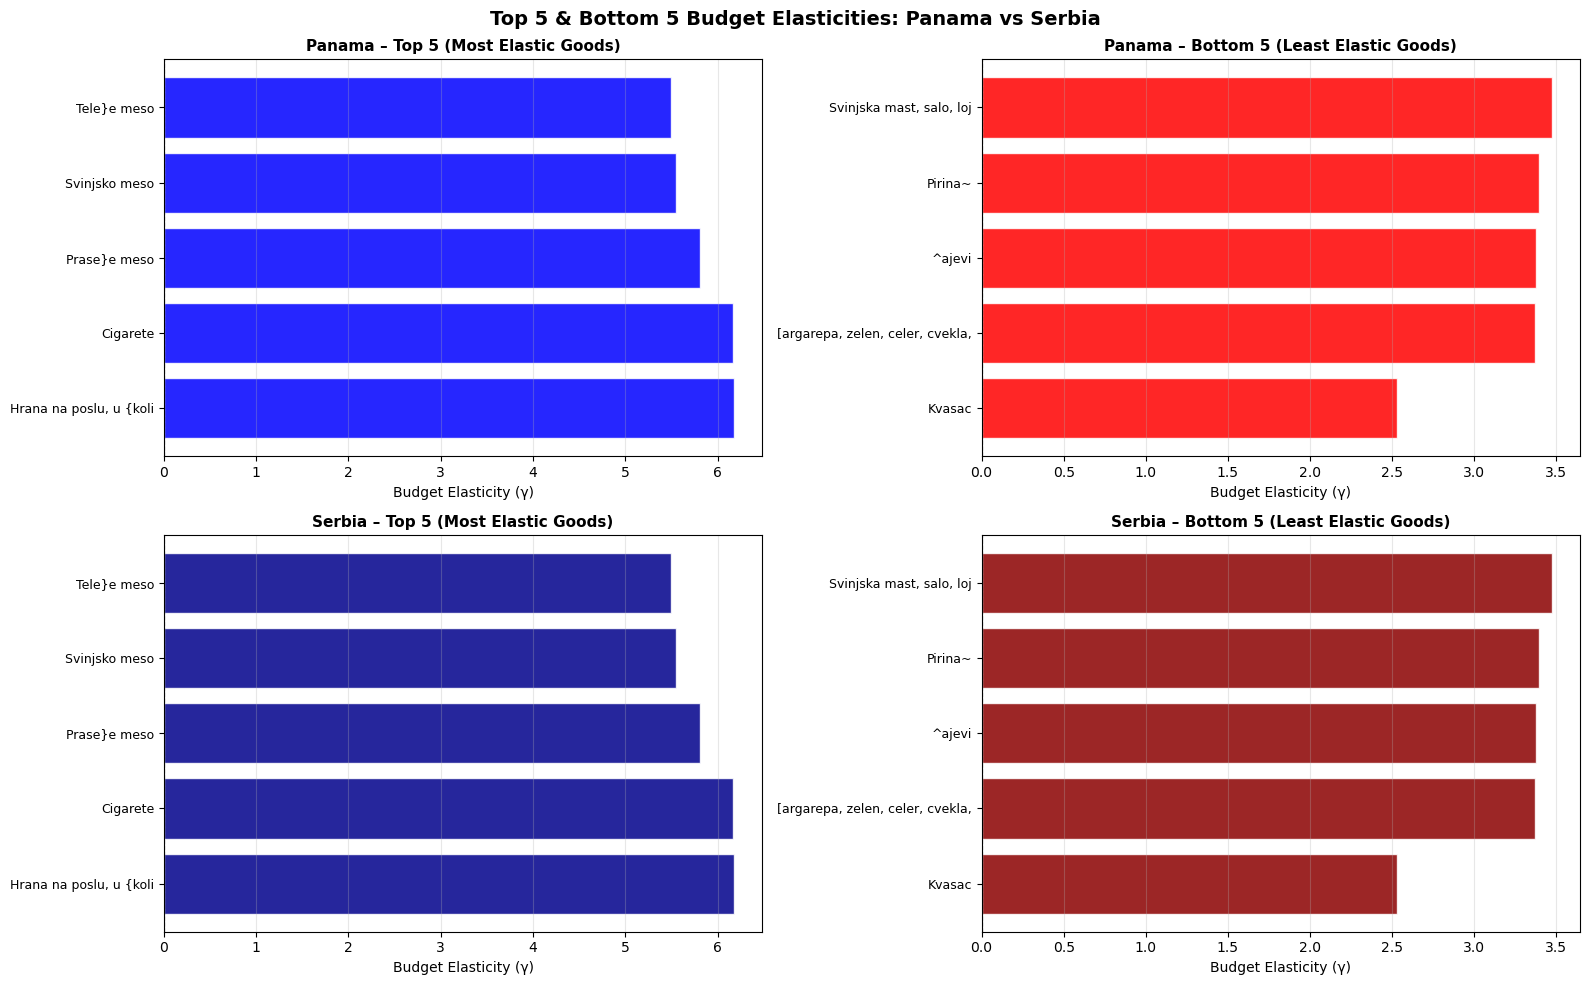

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Top 5 & Bottom 5 Budget Elasticities: Panama vs Serbia',
             fontsize=14, fontweight='bold')

datasets = [
    (pan_const.nlargest(5),  axes[0, 0], 'Panama – Top 5 (Most Elastic Goods)',   'blue'),
    (pan_const.nsmallest(5), axes[0, 1], 'Panama – Bottom 5 (Least Elastic Goods)', 'red'),
    (ser_const.nlargest(5),  axes[1, 0], 'Serbia – Top 5 (Most Elastic Goods)',    'darkblue'),
    (ser_const.nsmallest(5), axes[1, 1], 'Serbia – Bottom 5 (Least Elastic Goods)', 'darkred'),
]

for data, ax, title, color in datasets:
    ax.barh(data.index, data.values, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Budget Elasticity (γ)', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
# Reload raw food expenditure data
x_pan = read_sheets(Panama_data, sheet='Food Expenditures (2008)')
x_ser = read_sheets(Serbia_data, sheet='Food Expenditures (2007)')

# Unique foods in each dataset
foods_pan = sorted(x_pan['j'].dropna().unique())
foods_ser = sorted(x_ser['j'].dropna().unique())

print("Number of Panama foods:", len(foods_pan))
print("Number of Serbia foods:", len(foods_ser))

print("\nSample Panama foods:")
print(foods_pan[:25])

print("\nSample Serbia foods:")
print(foods_ser[:25])

Number of Panama foods: 81
Number of Serbia foods: 100

Sample Panama foods:
['Aceite Vegetal', 'Aguacates', 'Ahí Verde', 'Ajo', 'Alimento Infantil', 'Apio', 'Arroz', 'Arvejas', 'Azúcar', 'Café Y Té', 'Carne De Res', 'Carnes De Puerco', 'Cebolla', 'Cereales Y Cremas', 'Cervezas', 'Chocolates', 'Cigarrillo Y Tabaco', 'Cocos (Pipas)', 'Condimentos', 'Culanto, Perejil, Cebollina', 'Embutidos', 'Enlatados Y Envasados', 'Frijoles', 'Galletas / Pasteles Y Dulces', 'Gelatinas']

Sample Serbia foods:
['@ivinsko meso', 'Beli hleb', 'Cigarete', 'Crni i beli luk i praziluk', 'Crni, ra`ani, integralni hleb', 'D@em, kompot, slatko, marmelada', 'Doma}i, beli  sir (sve vrste)', 'Druge vrste `ita', 'Druge vrste hleba', 'Duvan', 'Gazirani i negazirani sokovi', 'Gotova jela', 'Gove|e meso', 'Gra{ak,boranija, sve` i zamrznut', 'Gro`|e', 'Hrana na poslu, u {koli', 'Hrana u restoranu (i poru~ena hrana koja se dostavlja na ku}u)', 'Hrana za odoj~ad', 'Instant supe', 'Jabuke', 'Jagnje}e i jare}e', 'Jaja (kok